In [1]:
!pip install hierarqcal

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 48.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.1/117.1 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.4/383.4 kB 27.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: jupyter-client
    Found existing installation: jupyter-client 6.1.12
    Uninstalling ju

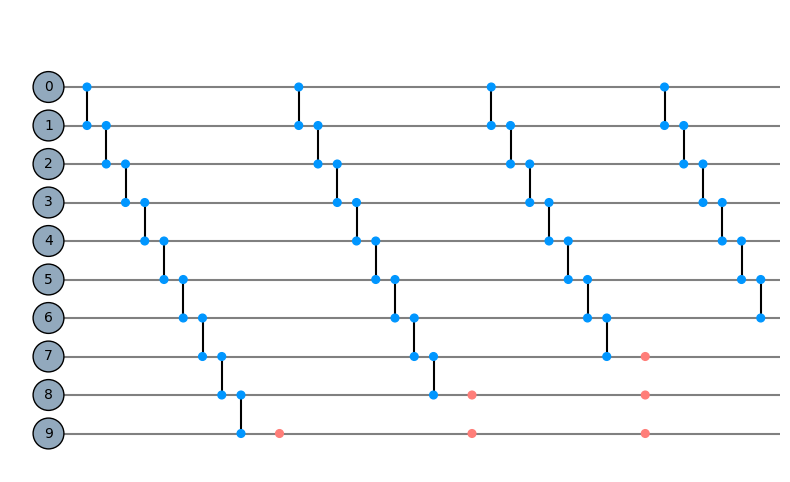

IndexError: list index out of range

In [10]:
from hierarqcal import (
    Qcycle,
    Qunitary,
    Qinit,
    Qmask,
    plot_circuit,
)

def comparator(bits, symbols=None, state=None):
    v1, v2 = state[bits[0]], state[bits[1]]
    if v1 > v2:
        state[bits[0]], state[bits[1]] = v2, v1
    return state

h_comparator = Qunitary(comparator, n_symbols=0, arity=2)
array = [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
nb = len(array)  # number of indices
hierq = Qinit(len(array), state=array) + (
    Qcycle(stride=1, step=1, offset=0, mapping=h_comparator, boundary="open") + Qmask("*1")
) * (nb - 1)

# Plot the circuit
plot_circuit(hierq)
sorted_array = hierq()
print(f"Starting array: {array}\nSorted array: {sorted_array}")


In [4]:
def bitonic_sort(array):
    def bitonic_merge(array, low, cnt, direction):
        if cnt > 1:
            k = cnt // 2
            for i in range(low, low + k):
                if (array[i] > array[i + k]) == direction:
                    array[i], array[i + k] = array[i + k], array[i]
            bitonic_merge(array, low, k, direction)
            bitonic_merge(array, low + k, k, direction)

    def bitonic_sort_recursive(array, low, cnt, direction):
        if cnt > 1:
            k = cnt // 2
            bitonic_sort_recursive(array, low, k, True)
            bitonic_sort_recursive(array, low + k, k, False)
            bitonic_merge(array, low, cnt, direction)

    bitonic_sort_recursive(array, 0, len(array), True)
    return array

# Implementing Bitonic Sort using HierarQcal
def bitonic_sort_hierarq(array):
    n = len(array)
    h_bitonic_sort = Qinit(n, state=array)
    for i in range(1, n):
        for j in range(i, 0, -1):
            asc = (i + j) % 2 == 0
            h_bitonic_sort += (
                Qcycle(stride=2 ** j, step=2 ** j, offset=0, mapping=h_comparator, boundary="open")
                + Qmask("*1")
            )
    return h_bitonic_sort()

# Demonstrate Bitonic Sort
array = [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
sorted_array = bitonic_sort(array.copy())
sorted_array_hierarq = bitonic_sort_hierarq(array.copy())

print(f"Starting array: {array}\nSorted array (Python): {sorted_array}")
print(f"Sorted array (HierarQcal): {sorted_array_hierarq}")


Starting array: [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
Sorted array (Python): [1, 2, 4, 5, 3, 6, 7, 7, 8, 7]
Sorted array (HierarQcal): [8, 1, 2, 4, 3, 5, 6, 7, 7, 7]


In [11]:
def cocktail_shaker_sort(array):
    n = len(array)
    swapped = True
    start = 0
    end = n - 1
    while swapped:
        swapped = False
        # Move from left to right
        for i in range(start, end):
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        if not swapped:
            break
        swapped = False
        end -= 1
        # Move from right to left
        for i in range(end - 1, start - 1, -1):
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        start += 1
    return array

# Implementing Cocktail Shaker Sort using HierarQcal
def cocktail_shaker_sort_hierarq(array):
    h_cocktail_shaker_sort = Qinit(len(array), state=array)
    n = len(array)
    swapped = True
    start = 0
    end = n - 1
    while swapped:
        swapped = False
        for i in range(start, end):
            h_cocktail_shaker_sort += (
                Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
            )
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        if not swapped:
            break
        swapped = False
        end -= 1
        for i in range(end - 1, start - 1, -1):
            h_cocktail_shaker_sort += (
                Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
            )
            if array[i] > array[i + 1]:
                array[i], array[i + 1] = array[i + 1], array[i]
                swapped = True
        start += 1
    return h_cocktail_shaker_sort()

# Demonstrate Cocktail Shaker Sort
array = [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
sorted_array = cocktail_shaker_sort(array.copy())
sorted_array_hierarq = cocktail_shaker_sort_hierarq(array.copy())

print(f"Starting array: {array}\nSorted array (Python): {sorted_array}")
print(f"Sorted array (HierarQcal): {sorted_array_hierarq}")


IndexError: list index out of range

In [12]:
def comb_sort(array):
    def get_next_gap(gap):
        gap = (gap * 10) // 13
        return max(1, gap)

    n = len(array)
    gap = n
    swapped = True
    while gap != 1 or swapped:
        gap = get_next_gap(gap)
        swapped = False
        for i in range(n - gap):
            if array[i] > array[i + gap]:
                array[i], array[i + gap] = array[i + gap], array[i]
                swapped = True
    return array

# Implementing Comb Sort using HierarQcal
def comb_sort_hierarq(array):
    h_comb_sort = Qinit(len(array), state=array)
    def get_next_gap(gap):
        gap = (gap * 10) // 13
        return max(1, gap)

    n = len(array)
    gap = n
    swapped = True
    while gap != 1 or swapped:
        gap = get_next_gap(gap)
        swapped = False
        for i in range(n - gap):
            h_comb_sort += (
                Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
            )
            if array[i] > array[i + gap]:
                array[i], array[i + gap] = array[i + gap], array[i]
                swapped = True
    return h_comb_sort()

# Demonstrate Comb Sort
array = [8, 5, 2, 1, 3, 4, 6, 7, 7, 7]
sorted_array = comb_sort(array.copy())
sorted_array_hierarq = comb_sort_hierarq(array.copy())

print(f"Starting array: {array}\nSorted array (Python): {sorted_array}")
print(f"Sorted array (HierarQcal): {sorted_array_hierarq}")


IndexError: list index out of range

In [15]:
def cocktail_shaker_sort_hierarq(array):
    h_cocktail_shaker_sort = Qinit(len(array), state=array)
    n = len(array)
    swapped = True
    start = 0
    end = n - 1
    while swapped:
        swapped = False
        for i in range(start, end):
            if i + 1 < len(array):  # Ensure index is within bounds
                h_cocktail_shaker_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + 1]:
                    array[i], array[i + 1] = array[i + 1], array[i]
                    swapped = True
        if not swapped:
            break
        swapped = False
        end -= 1
        for i in range(end - 1, start - 1, -1):
            if i + 1 < len(array):  # Ensure index is within bounds
                h_cocktail_shaker_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + 1]:
                    array[i], array[i + 1] = array[i + 1], array[i]
                    swapped = True
        start += 1
    return h_cocktail_shaker_sort()



In [16]:
def comb_sort_hierarq(array):
    h_comb_sort = Qinit(len(array), state=array)
    def get_next_gap(gap):
        gap = (gap * 10) // 13
        return max(1, gap)

    n = len(array)
    gap = n
    swapped = True
    while gap != 1 or swapped:
        gap = get_next_gap(gap)
        swapped = False
        for i in range(n - gap):
            if i + gap < len(array):  # Ensure index is within bounds
                h_comb_sort += (
                    Qcycle(stride=1, step=1, offset=i, mapping=h_comparator, boundary="open") + Qmask("*1")
                )
                if array[i] > array[i + gap]:
                    array[i], array[i + gap] = array[i + gap], array[i]
                    swapped = True
    return h_comb_sort()
